# Overview

This notebook is the main code interface to present the thesis made by Shan Schleusner. All the experiments made through the thesis are replicated below and follow closely the chapter order made in the pdf version.

We invite the lector to read the code by themselves whenever they are curious about a specific implementation detail. We also encourage the lector to perform their own experiment in this notebook with the implemented functions whenever they are seeking to investigate a specific point of the thesis. 



First, we invite you to download the following packages in your prefered environment.


In [6]:
%pip install pandas
%pip install pyarrow
%pip install haversine
%pip install scikit-learn
%pip install skorch
%pip install torch
%pip install lightgbm
%pip install xgboost
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


To communicate with the different function, calling the class ALStudy is sufficient as this class acts like an Orchestrator function. This will become clear when reading through this work. As a first step, we will import the class to check that it imports correctly.

In [1]:
from src.active_learning_study import ALStudy
study = ALStudy()

# Dataset Presentation

This part follows the chapter Dataset Presentation. We mainly introduce the original dataset, investigate the different features and their distributions and analyze the characteristics of the data. We also analyse the distribution of the data post distribution between L and U. 

First, we will load the original dataset (unprocessed)

In [2]:
study.load_D()

Then, we can retrieve from the dataset informations related to the highway, max speed and lanes. We mainly report the counts and their distribution.

In [ ]:
highway, speed, lanes = study.get_basic_features_analysis_from_D()
space = "\n" + "#"*50 + "\n"

print(highway)
print(space)
print(speed)
print(space)
print(lanes)

It is also possible to plot the highway types on a map to realize the spatial dispersion (~45 seconds)

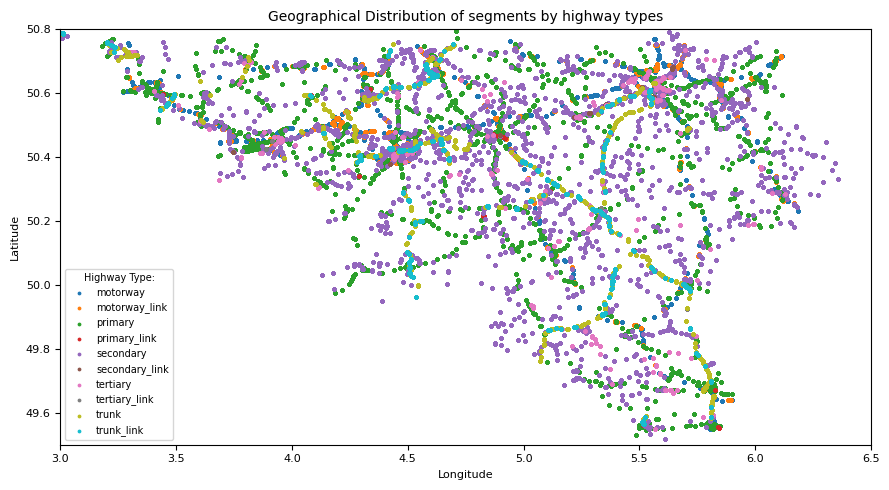

In [4]:
study.print_map_D()

We can now study deeper the target which represents a measurement of traffic flow (for details, i invite to consult the thesis). We can see in the figures below the typical traffic variation for a week and for a month and also how the traffic can change different distribution according to the highway types

In [ ]:
count = study.get_target_analysis_from_D()
print(count)


Finally, we can end the analysis by comparing the dataset L and U splitted from D. First, we print the table of the highway distribution of L and U respectively. Then, we show the spatial distribution of L.

In [2]:
table_L, table_U = study.analyze_U_and_L_distribution()
print(table_L)
print(table_U)

                                Highway type  Count  Percentage
highway_secondary          highway_secondary      4        0.86
highway_primary              highway_primary     29        6.21
highway_motorway_link  highway_motorway_link     65       13.92
highway_trunk                  highway_trunk     17        3.64
highway_motorway            highway_motorway    351       75.16
highway_tertiary            highway_tertiary      1        0.21
highway_trunk_link        highway_trunk_link      0        0.00
7                                      Total    467      100.00
                                Highway type  Count  Percentage
highway_secondary          highway_secondary   3322       36.43
highway_primary              highway_primary   2496       27.37
highway_motorway_link  highway_motorway_link    883        9.68
highway_trunk                  highway_trunk    846        9.28
highway_motorway            highway_motorway    708        7.76
highway_tertiary            highway_tert

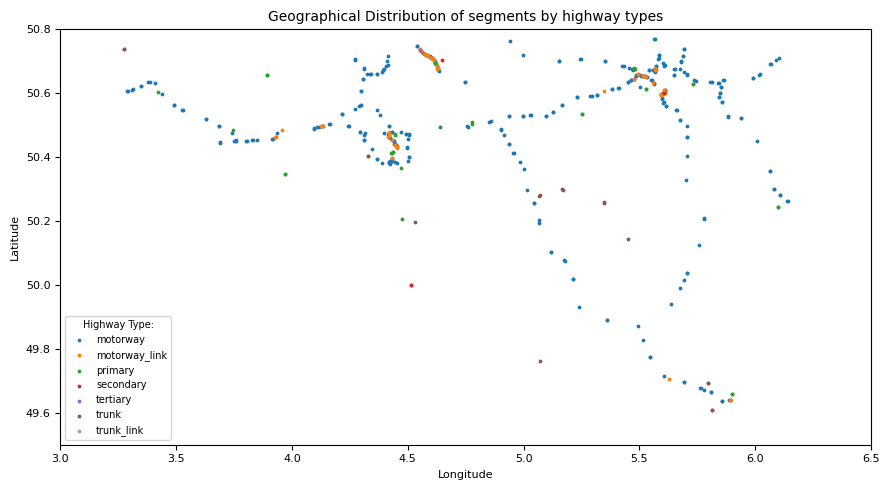

In [2]:
study.print_L_map()

# Feature Engineering

This part mainly analyzes the addition of the new features. Since we are entering to the experimental phase of the thesis, the labelled set, the unlabelled set and the evaluation sets need to be loaded to be able to perform any of the following steps. The current repository already provides the processed ressourced in "data.processed_datasets" in order to avoid time-consuming preprocessing steps when launching experiments. However, if for any reason the all the ressources from that folder was erased, we invite to uncomment the following cells. The processing time is ~8 minutes.

If the processed_dataset folder is not empty, you can ignore this step.

In [3]:
#study.load_D()
#study.build_split_labelled_unlabelled()

The seeds decide the random parameter used for the experiment. By default, the seeds are set to {1, 2, 3, 4, 5}. If the lector wants to test the code with other seeds, please run the cell below (This steps takes ~1 second).

In [ ]:
seeds = [1, 2, 3, 4, 5]
study.set_seeds_experiment(seeds)

Here we evaluate the usefulness of the additional features introduced in the dataset. We start with the basic road features (X_base) then add the distance, connectivity and spatial density features one by one. For each version, the cross-validation steps was runned several times with different seeds. The goal is to see which group of features improves the predictions. Running time takes up to 7 minutes.

In [ ]:
study.apply_additional_features_experiment(seeds)

# Parameters tuning

This part makes use of the validation set in order to tune the Random Forest and the batch-size. It follows closely the chapter Methodology of the thesis.

In [2]:
from src.active_learning_study import ALStudy
from src.common import UNIFORM_RANDOM_SAMPLING, STRATIFIED_RANDOM_SAMPLING, RANDOM_SAMPLING_HIGH_TRAFFIC_ONLY, UNCERTAINTY_ONLY, FURTHEST_SAMPLING, HYBRID
study = ALStudy()
seeds = [1, 2, 3, 4, 5]

In this cell, we tune the Random Forest parameters before running the full active learning experiments. We test several combinations of values for the main hyperparameters: the number of estimators, maximum depth, minimum split size and minimum leaf size.

We do this over several seeds so that the selected parameters are not only good for one random split. For each combination, we evaluate the model on the validation set and compare the MSE and keep the parameter setting that gives the best average result across seeds.

In [2]:
study.tune_models_parameters(seeds)

Best parameters:
 n_estimators: 100
 max_depth: None
 min_samples_split: 2
 min_samples_leaf: 5
 max_features: 1.0
 mean_mse: 69.42699275642879


In this cell, we determine the most suitable batch size for the active learning process. We compare three different batch sizes (25, 50, and 100) while keeping the total annotation budget fixed at 300 road segments.

To make the comparison as fair as possible, we use the Hybrid to compare the datapoints selections (see thesis). Each configuration is tested over several seeds and we compare the average performance to select the batch size used in the next experiments.

The experiment lasts fifteen to twenty minutes due to the speed of the hybrid method.

In [2]:
study.analyse_batch_parameter(seeds)

25
  1
  2
  3
  4
  5
Batch 25: mean=33.07421899026845, std=3.6465060649477135
50
  1
  2
  3
  4
  5
Batch 50: mean=32.57223452970935, std=3.665210336046838
100
  1
  2
  3
  4
  5
Batch 100: mean=35.407272405337984, std=5.1058275760965035


# Strategies comparison

The lector can call functions here to evaluate alone the performance of a learning strategy. The batch_size, budget and seeds can be changed to test different settings. Simply uncomment the strategy you want to run.

The Hybrid strategy is the most computationally expensive and takes a bit less than fifteen minutes to complete with the default settings. Random methods are the fastest.

In [ ]:
from src.common import UNIFORM_RANDOM_SAMPLING, STRATIFIED_RANDOM_SAMPLING, RANDOM_SAMPLING_HIGH_TRAFFIC_ONLY, UNCERTAINTY_ONLY, FURTHEST_SAMPLING, HYBRID
from src.active_learning_study import ALStudy
study = ALStudy()
seeds = [1, 2, 3, 4, 5]
batch_size = 25
budget = 500

#study.analyse_performance_strategy(UNIFORM_RANDOM_SAMPLING, batch_size, budget, seeds)
#study.analyse_performance_strategy(RANDOM_SAMPLING_HIGH_TRAFFIC_ONLY, batch_size, budget, seeds)
#study.analyse_performance_strategy(FURTHEST_SAMPLING, batch_size, budget, seeds)
#study.analyse_performance_strategy(UNCERTAINTY_ONLY, batch_size, budget, seeds)
#study.analyse_performance_strategy(HYBRID, batch_size, budget, seeds)

In the cell below, we report the maximum accuracy that the algorithm can reach after adding the full unlabelled dataset. We can see the results in term of R2, MSE and MAE MR.

Average results:
R2: 0.8626648825095155
MSE: 23.483022686080528
MAE MR: 1.5531296559401224
-------------------
Std R2: 0.021414760733783803
Std MSE: 4.82098905189996
Std MAE MR: 0.0853509834207864


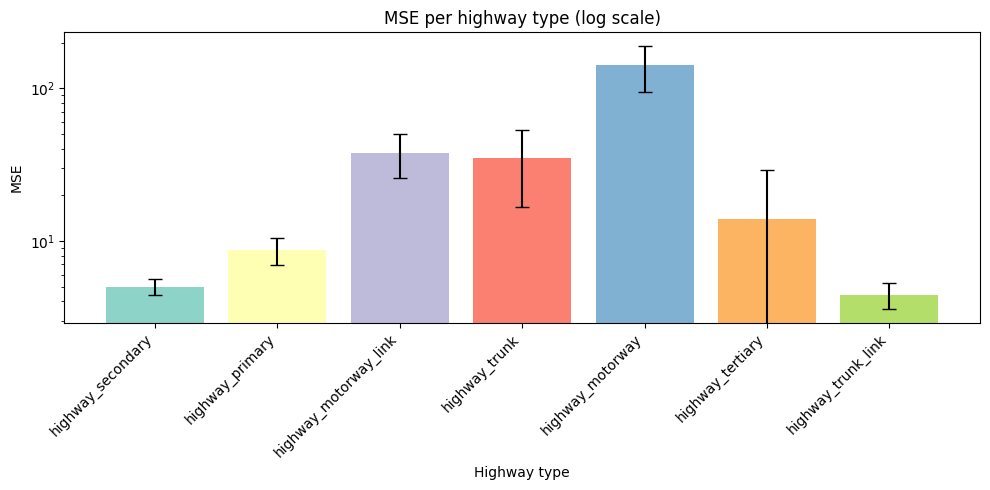

In [2]:
study.analyse_max_accuracy(seeds)

We  compare the different active learning strategies in the following cells. The cells below run each strategy and evaluate its performance when the labeling budget increases. Hybrid takes seven minutes, Random strategies one minute and the others are intermediary.

   dps selection done
   dps selection done
   dps selection done
   dps selection done
   dps selection done


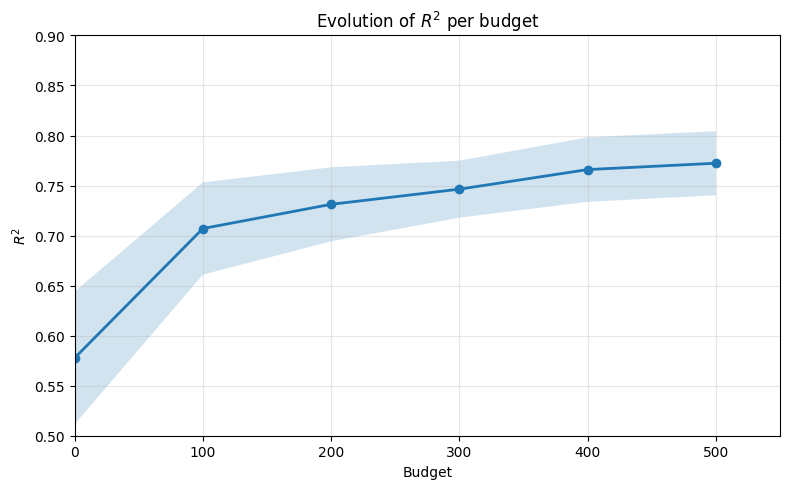

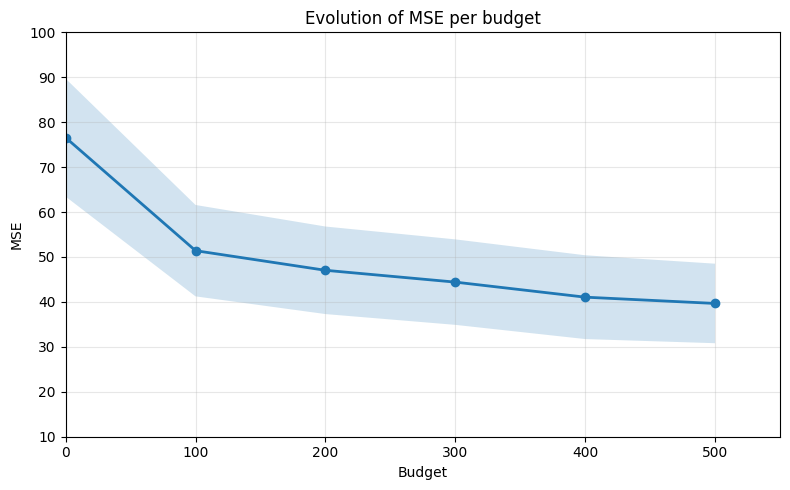

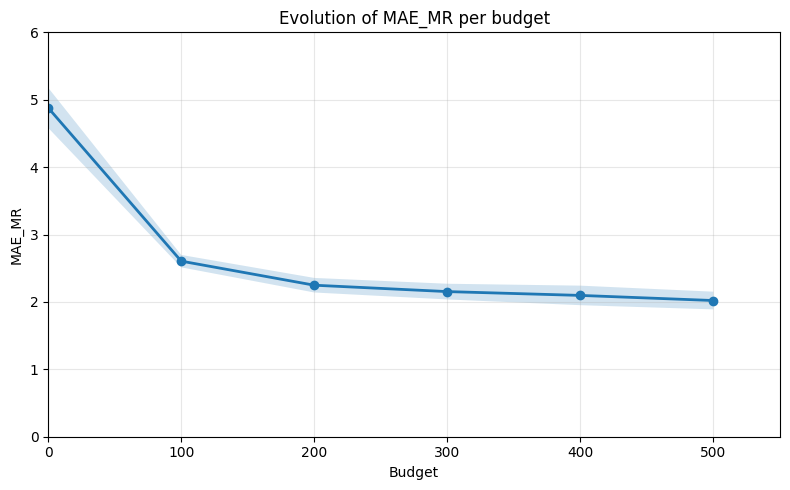

 budget   avg_r2   std_r2   avg_mse   std_mse  avg_mae_mr  std_mae_mr
      0 0.577698 0.066208 76.564790 13.121471    4.880579    0.297534
    100 0.707044 0.046118 51.407023 10.168939    2.605314    0.092113
    200 0.731236 0.036975 47.040550  9.742404    2.248047    0.108018
    300 0.746388 0.028476 44.409038  9.512528    2.153369    0.116439
    400 0.765939 0.032234 41.059850  9.324107    2.096575    0.144971
    500 0.772309 0.032027 39.660949  8.848770    2.020712    0.131188


In [2]:
study.analyse_performance_strategy_per_budget_threshold(UNIFORM_RANDOM_SAMPLING, seeds)

   dps selection done
   dps selection done
   dps selection done
   dps selection done
   dps selection done


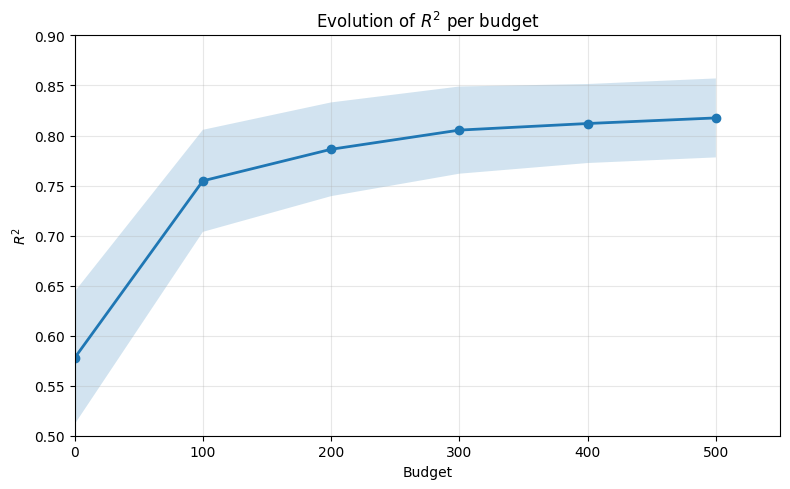

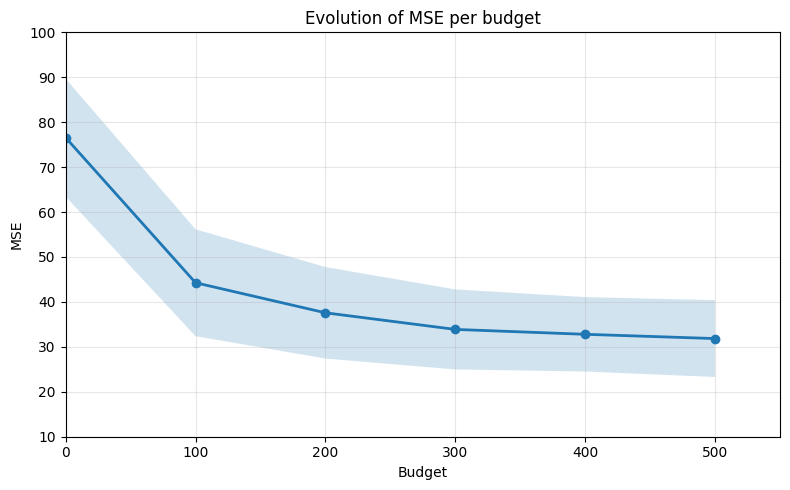

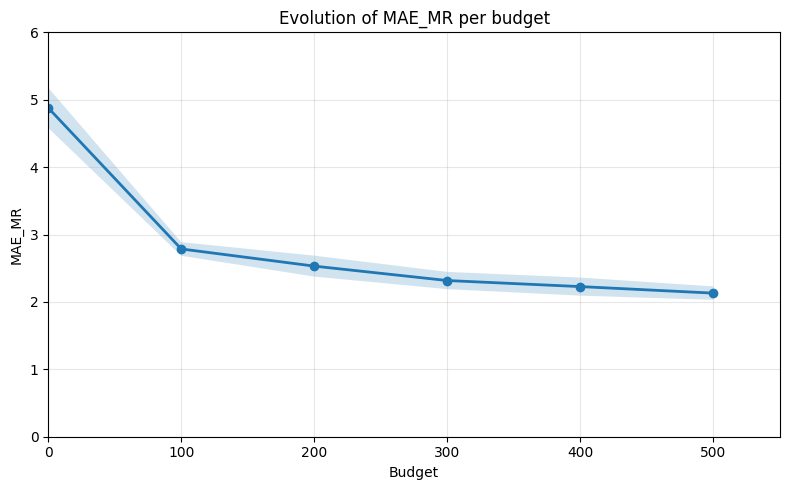

 budget   avg_r2   std_r2   avg_mse   std_mse  avg_mae_mr  std_mae_mr
      0 0.577698 0.066208 76.564790 13.121471    4.880579    0.297534
    100 0.754700 0.050986 44.269355 11.896779    2.786044    0.100996
    200 0.786241 0.046829 37.581606 10.183405    2.531265    0.155640
    300 0.805404 0.043558 33.880823  8.904156    2.317312    0.127978
    400 0.811980 0.039476 32.795156  8.279838    2.227445    0.134219
    500 0.817576 0.039452 31.844299  8.550805    2.130350    0.099619


In [3]:
study.analyse_performance_strategy_per_budget_threshold(HYBRID, seeds)

   dps selection done
   dps selection done
   dps selection done
   dps selection done
   dps selection done


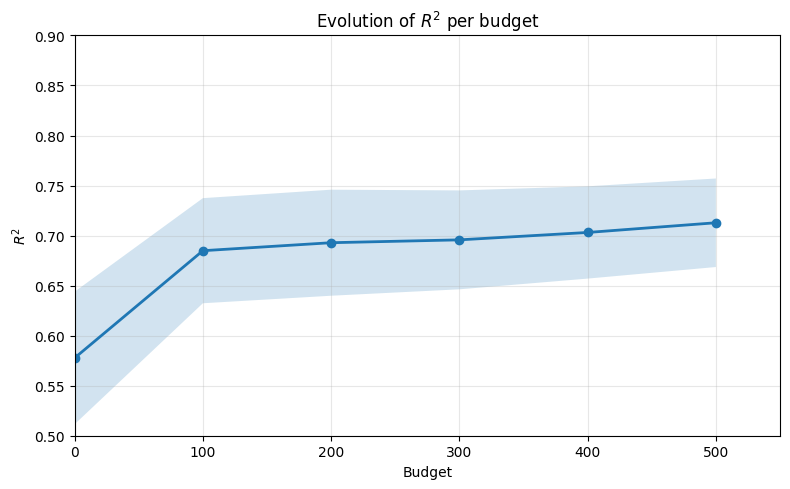

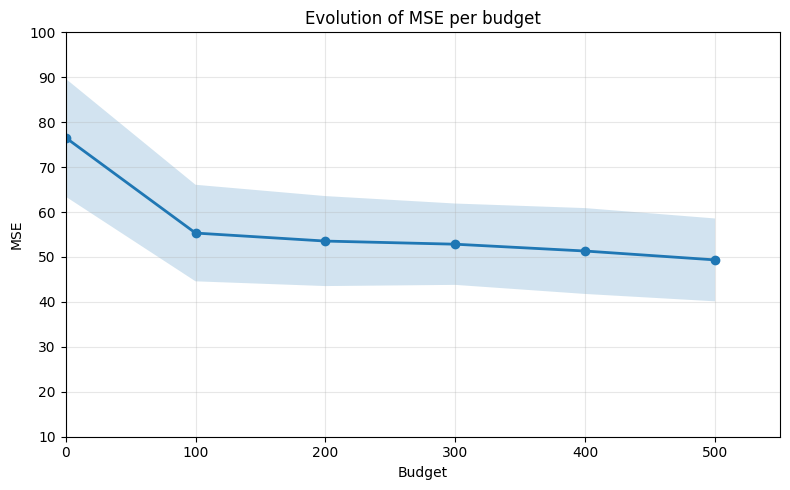

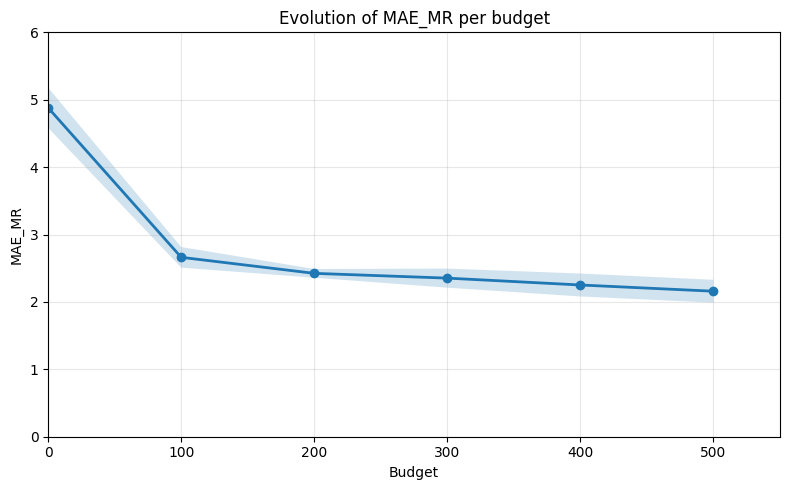

 budget   avg_r2   std_r2   avg_mse   std_mse  avg_mae_mr  std_mae_mr
      0 0.577698 0.066208 76.564790 13.121471    4.880579    0.297534
    100 0.684889 0.052517 55.329138 10.742953    2.661814    0.153005
    200 0.692875 0.052982 53.543612 10.013715    2.423928    0.065068
    300 0.695719 0.049416 52.846274  9.051207    2.353147    0.141779
    400 0.703110 0.046097 51.327853  9.553976    2.251302    0.170300
    500 0.712815 0.044238 49.352954  9.220129    2.158793    0.169799


In [4]:
study.analyse_performance_strategy_per_budget_threshold(STRATIFIED_RANDOM_SAMPLING, seeds)

   dps selection done
   dps selection done
   dps selection done
   dps selection done
   dps selection done


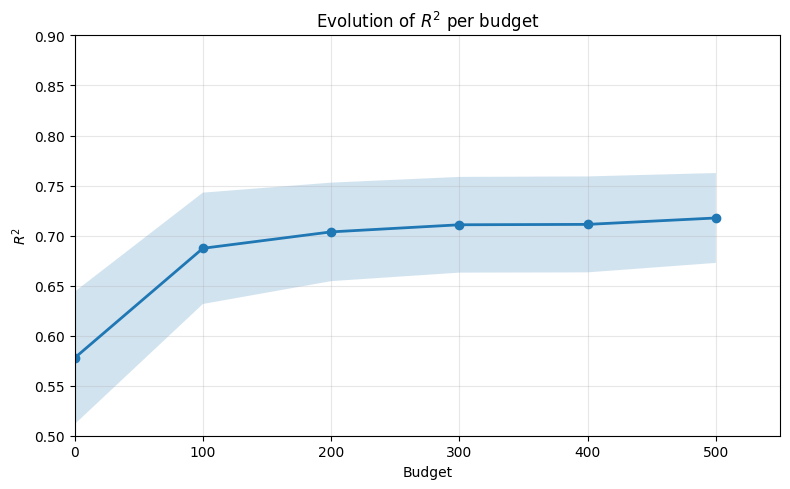

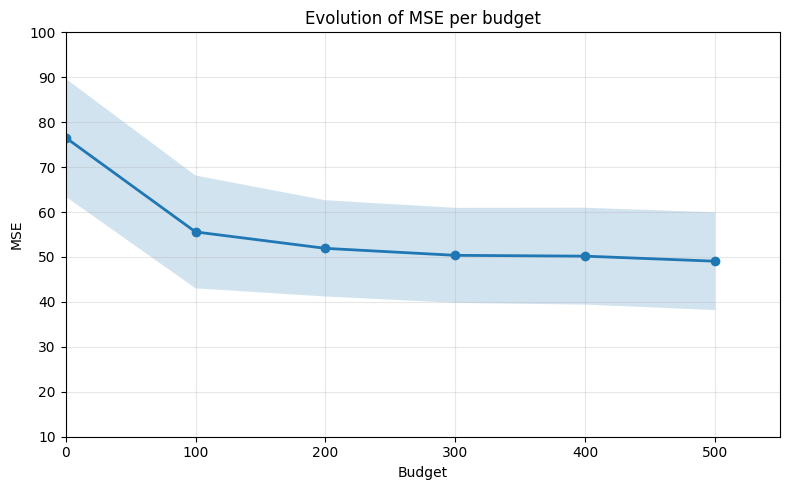

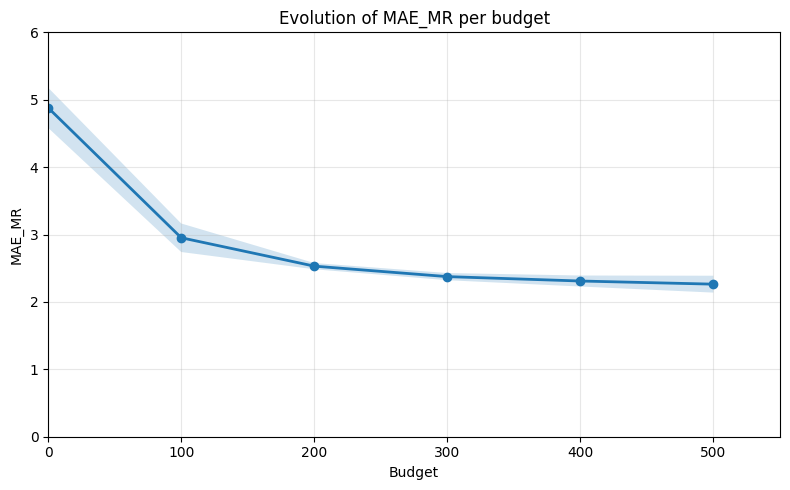

 budget   avg_r2   std_r2   avg_mse   std_mse  avg_mae_mr  std_mae_mr
      0 0.577698 0.066208 76.564790 13.121471    4.880579    0.297534
    100 0.687278 0.055641 55.578489 12.553443    2.952352    0.211629
    200 0.703693 0.049217 51.923503 10.713153    2.530909    0.046418
    300 0.710799 0.047835 50.370074 10.570214    2.375501    0.053216
    400 0.711185 0.047941 50.186951 10.781092    2.310254    0.081560
    500 0.717601 0.044908 49.062475 10.876927    2.263582    0.125220


In [5]:
study.analyse_performance_strategy_per_budget_threshold(FURTHEST_SAMPLING, seeds)

   dps selection done
   dps selection done
   dps selection done
   dps selection done
   dps selection done


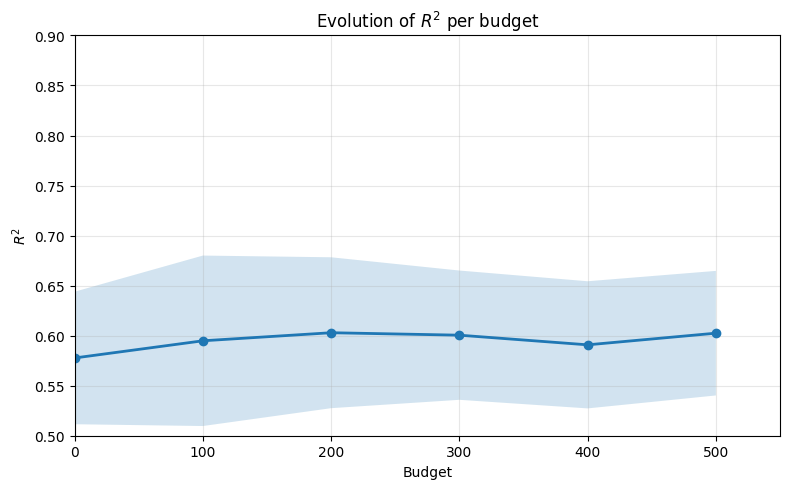

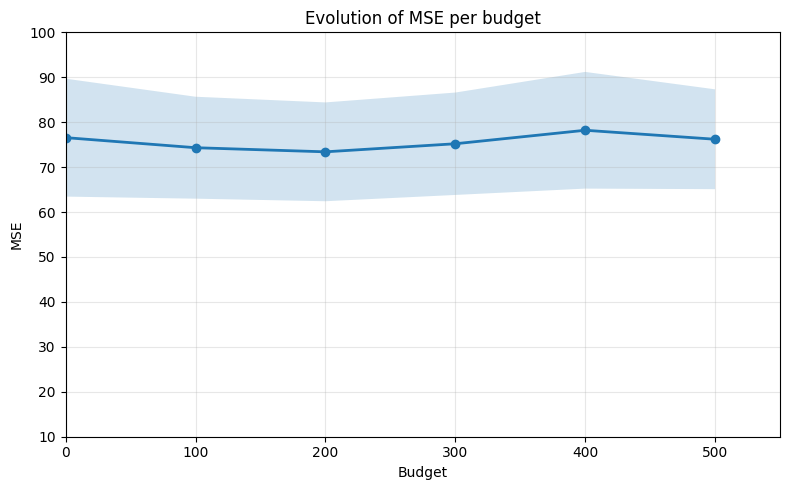

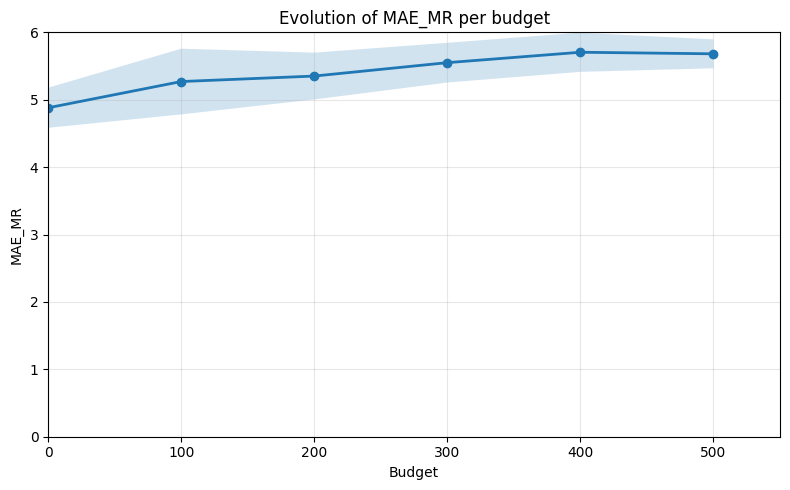

 budget   avg_r2   std_r2   avg_mse   std_mse  avg_mae_mr  std_mae_mr
      0 0.577698 0.066208 76.564790 13.121471    4.880579    0.297534
    100 0.594859 0.085165 74.322943 11.343939    5.269858    0.487374
    200 0.602920 0.075396 73.405703 10.995360    5.351365    0.347473
    300 0.600473 0.064590 75.202712 11.393673    5.550131    0.294839
    400 0.590830 0.063528 78.205474 12.984752    5.704518    0.291062
    500 0.602474 0.062237 76.206081 11.110181    5.681151    0.214476


In [6]:
study.analyse_performance_strategy_per_budget_threshold(RANDOM_SAMPLING_HIGH_TRAFFIC_ONLY, seeds)

   dps selection done
   dps selection done
   dps selection done
   dps selection done
   dps selection done


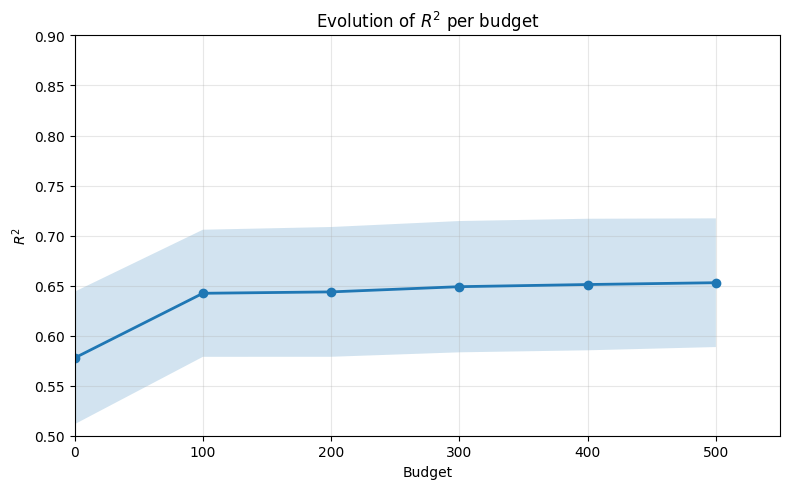

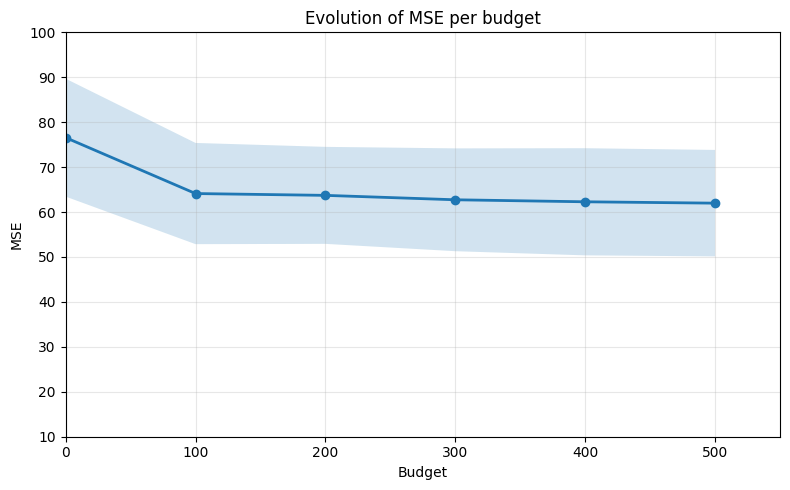

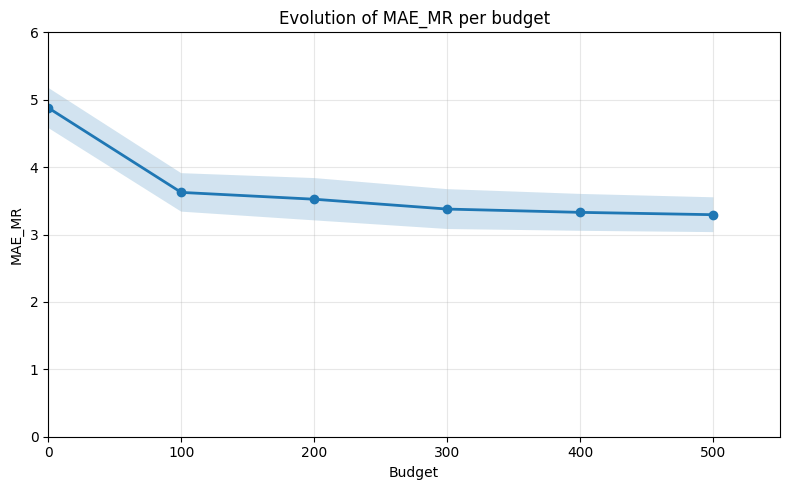

 budget   avg_r2   std_r2   avg_mse   std_mse  avg_mae_mr  std_mae_mr
      0 0.577698 0.066208 76.564790 13.121471    4.880579    0.297534
    100 0.642338 0.063505 64.120618 11.261638    3.625117    0.285382
    200 0.643731 0.064842 63.716337 10.794051    3.523824    0.313804
    300 0.648938 0.065594 62.733326 11.442581    3.377682    0.295583
    400 0.651087 0.065728 62.287054 11.924069    3.328811    0.273648
    500 0.652910 0.064297 61.982282 11.845152    3.294111    0.258359


In [7]:
study.analyse_performance_strategy_per_budget_threshold(UNCERTAINTY_ONLY, seeds)

We compare all the query strategies on the same plots here to see visually which strategy perform the best. It is plotted in R^2 and in MAE MR. Since the results are loaded from previous computations, the plot is traced in few milliseconds.

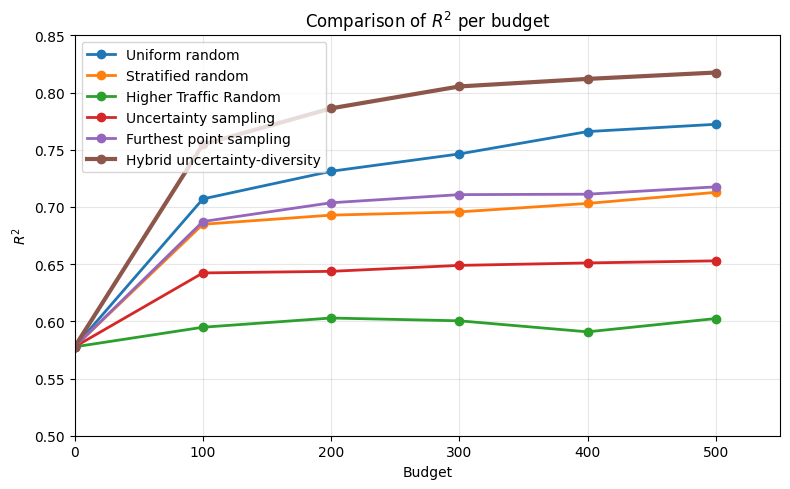

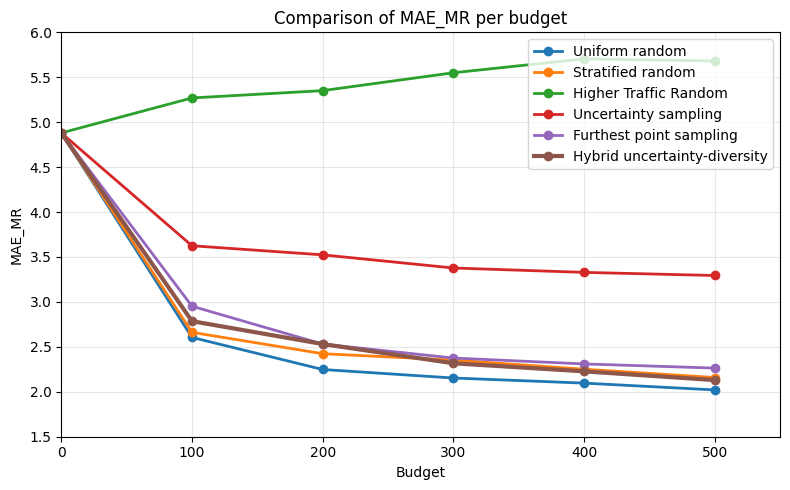

In [9]:
study.compare_different_strategy()

# Hybrid Selection Analysis

This part is the final section of our thesis. We effectuate a deeper analysis of our hybrid strategy. The aim of this section is to understand what choices do the strategy make to be efficient. The second objective is to understand what are the characteristics of the selected datapoints and in which proportion a certain type of datapoints is selected.

First, lets initialise the variables if its not done already.

In [1]:
from src.active_learning_study import ALStudy
study = ALStudy()
seeds = [1, 2, 3, 4, 5]

The execution time of this function takes about fifteen minutes and show a fine granularity evolution per batch of twenty five.

After this, the results were already saved from the runs done in the previous sections so the execution of the following parts should take maximum couple of seconds. 

   dps selection done
   dps selection done
   dps selection done
   dps selection done
   dps selection done


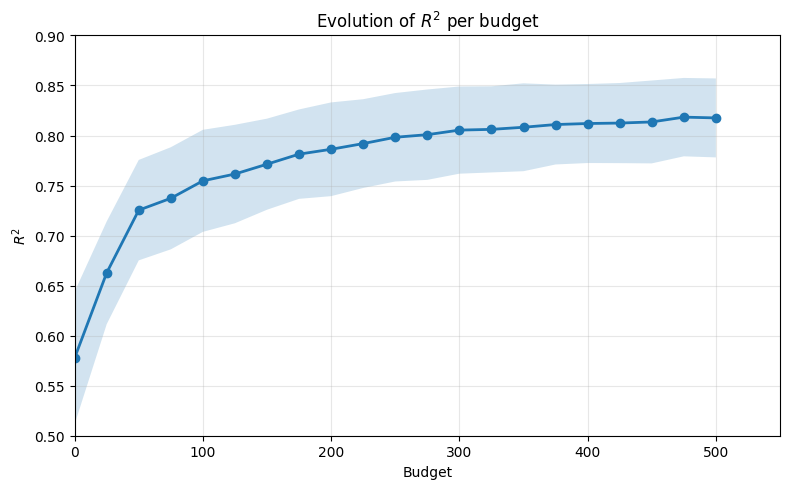

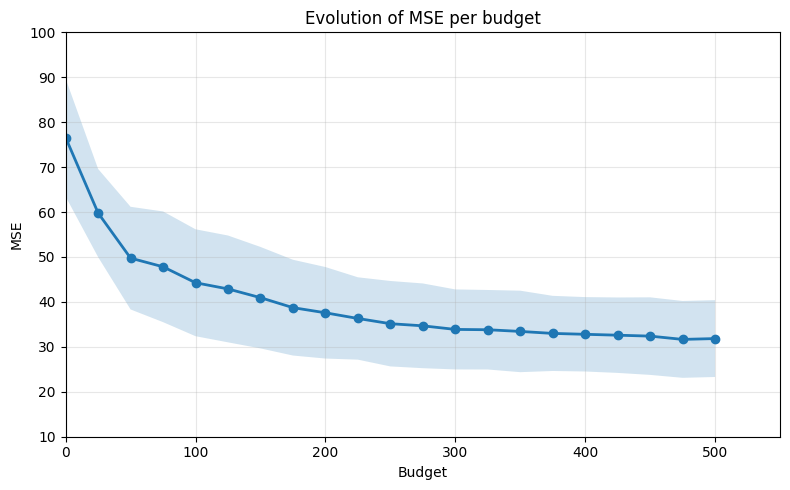

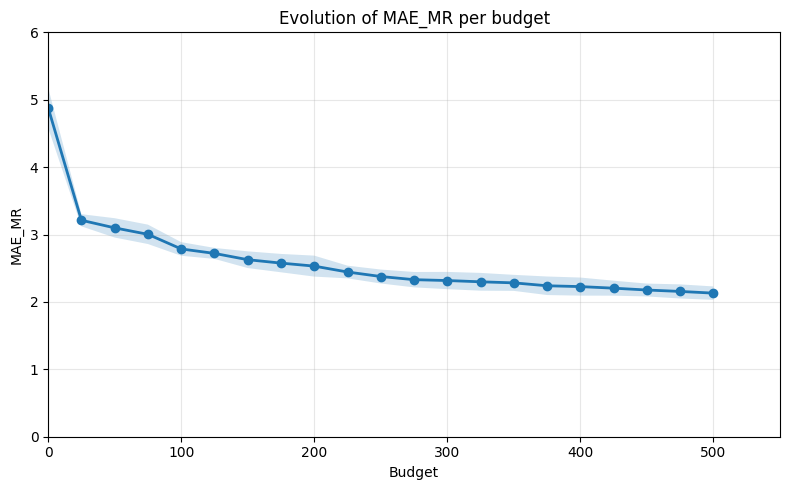

 budget   avg_r2   std_r2   avg_mse   std_mse  avg_mae_mr  std_mae_mr
      0 0.577698 0.066208 76.564790 13.121471    4.880579    0.297534
     25 0.662760 0.051314 59.784973  9.806724    3.211624    0.090271
     50 0.725409 0.050181 49.747929 11.424154    3.098743    0.143474
     75 0.737262 0.051011 47.819479 12.317199    3.002931    0.143734
    100 0.754700 0.050986 44.269355 11.896779    2.786044    0.100996
    125 0.761512 0.049195 42.892966 11.887828    2.719765    0.081388
    150 0.771337 0.045512 40.947026 11.290012    2.626568    0.123855
    175 0.781376 0.044670 38.727506 10.657995    2.575873    0.136237
    200 0.786241 0.046829 37.581606 10.183405    2.531265    0.155640
    225 0.791924 0.044343 36.317693  9.163981    2.443831    0.094183
    250 0.798253 0.044188 35.154340  9.506286    2.376935    0.103452
    275 0.800824 0.045158 34.681985  9.430618    2.330169    0.114096
    300 0.805404 0.043558 33.880823  8.904156    2.317312    0.127978
    325 0.806129 0.0

In [2]:
study.analyse_hybrid_per_budget_threshold(seeds)

We can then start the analysis of the composition of road types per batch. Then, we make a comparison between the composition of the real network, the acquisition made by AL, and the dataset made from AL acquistions with the labelled dataset. Finally, we can see across seeds whats the usual composition of the acquisitions.

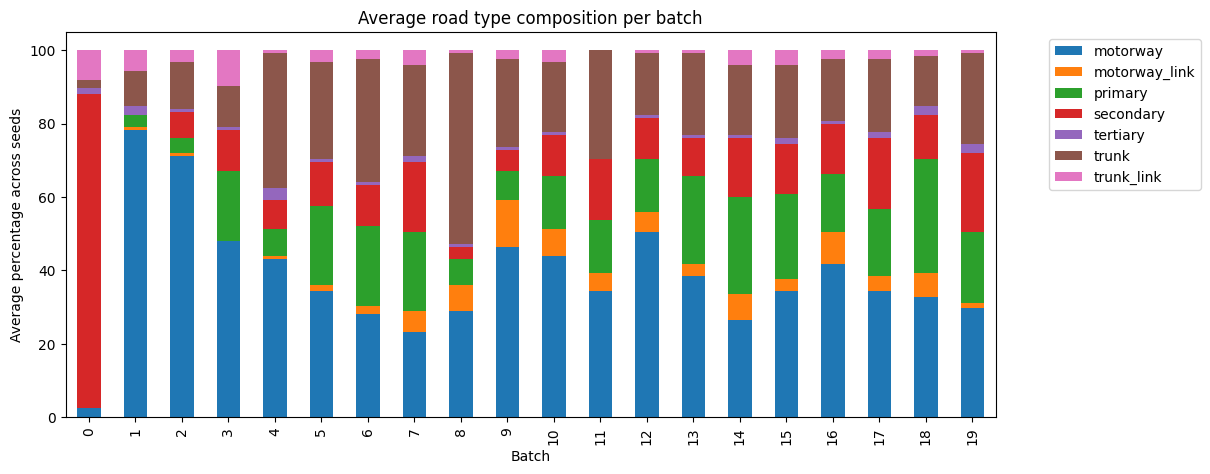

               full_dataset_%  al_acquisition_%  final_labelled_%
secondary               34.69             15.44             13.14
primary                 26.34             15.76             14.26
motorway                11.05             38.52             44.29
motorway_link            9.89              4.20              5.73
trunk                    9.00             21.80             18.94
trunk_link               4.78              3.00              2.53
tertiary                 4.26              1.28              1.11
               mean_%  std_%
motorway        38.52   3.82
trunk           21.80   1.30
primary         15.76   2.60
secondary       15.44   1.28
motorway_link    4.20   1.15
trunk_link       3.00   0.20
tertiary         1.28   0.27


In [2]:
study.analyse_road_type_composition(seeds)

In this part, we can analyse which segments are selected per batch for a specific seed. Lighter blue means that the segment was queried for labellisation early while red means that the segment was queried later. 

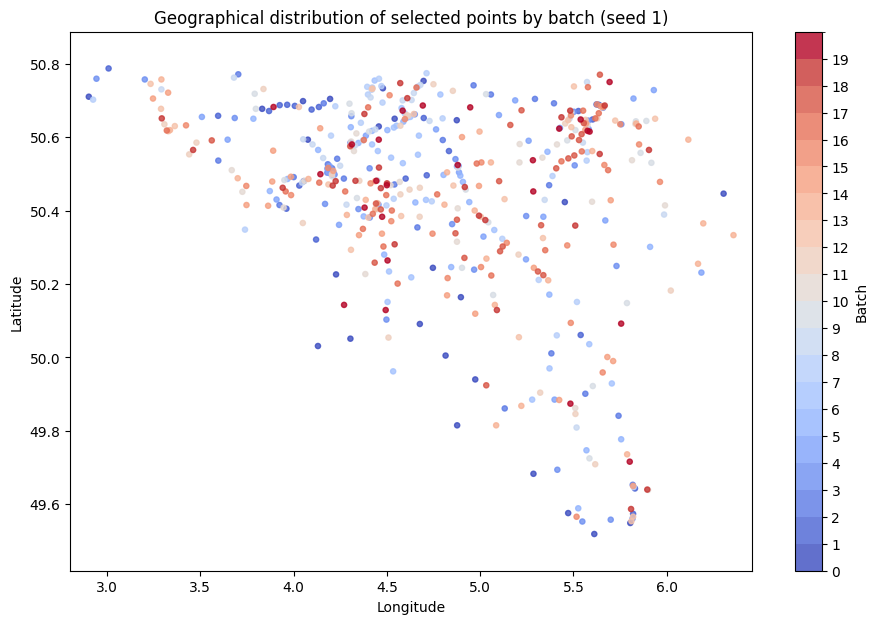

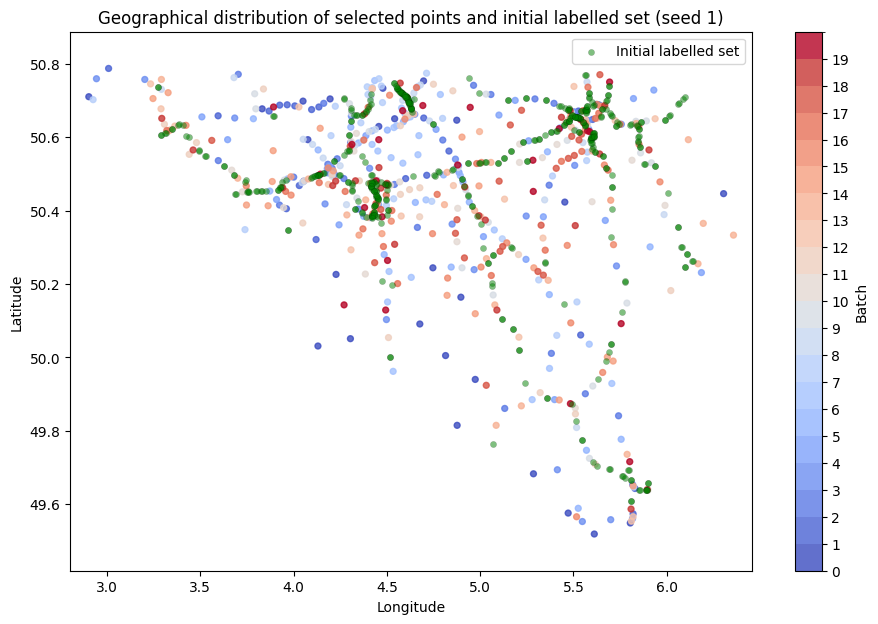

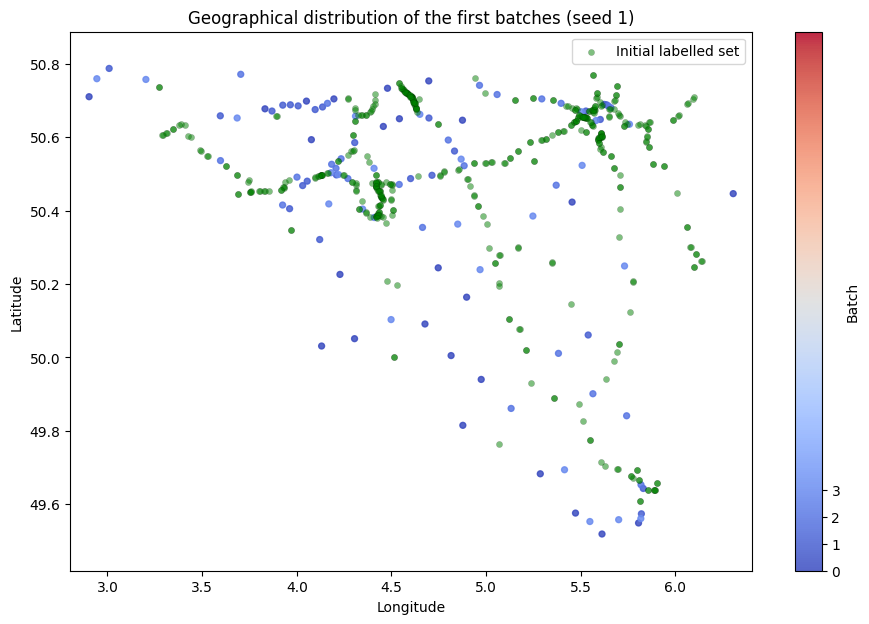

In [8]:
seed = 1
study.analyse_geography_hybrid(seed)

This section analyses for a given seed if the same datapoints are selected between runs and also in which batches they are more common to appear. Finally, it shows on the map where these datapoints are geographically situated

   n_seeds  n_points  percentage
0        1       488       44.24
1        2       219       19.85
2        3       144       13.06
3        4       118       10.70
4        5       134       12.15
   n_seeds  n_points  mean_batch  std_batch  avg_min_batch  avg_max_batch  \
0        1       488       11.59       5.66          11.59          11.59   
1        2       219       10.66       5.30           9.37          11.94   
2        3       144       10.36       5.79           8.63          12.17   
3        4       118        8.92       4.64           6.65          11.61   
4        5       134        7.08       4.66           5.35           9.00   

   percentage  
0       44.24  
1       19.85  
2       13.06  
3       10.70  
4       12.15  


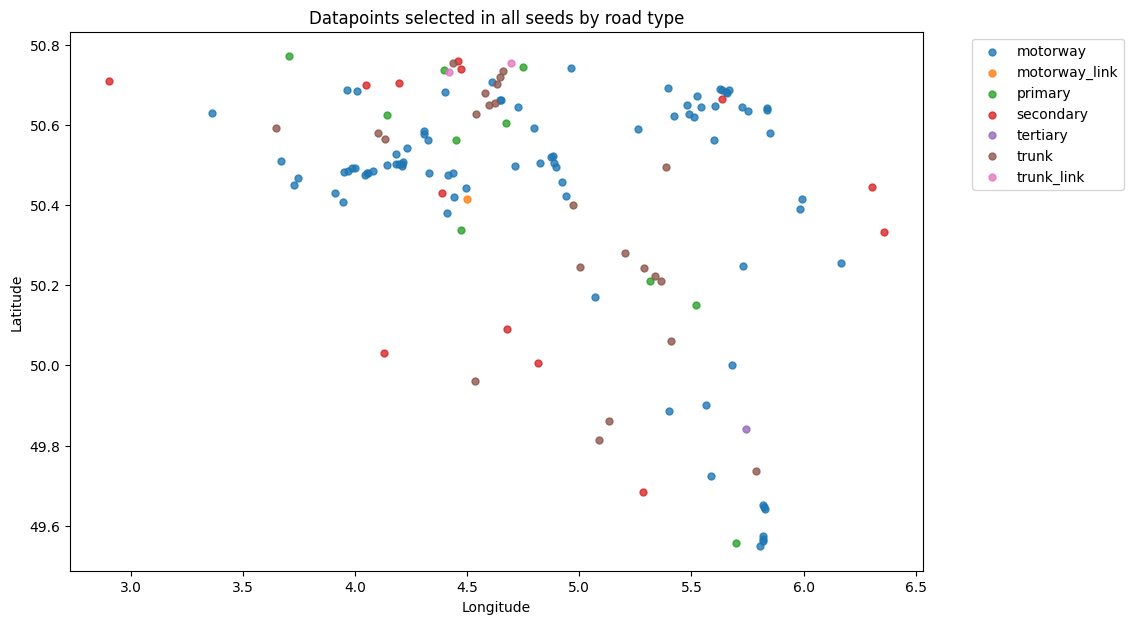

In [4]:
study.analyse_recurrence_hybrid(seeds)

For the final part of this thesis, we plot the score given by the hybrid algorithm for every segment at batch zero. On the first plot, the diversity score is normalised between zero and one where closer to zero shows weak diversity and red high diversity. We can notice the spread of the datapoints across the maap where region labelissed are more often blue. On the second plot, we can see that the model is uncertain only really about area located to Brussels where high traffic can be noticed. On the last one, we see the product of the two where for the first batch, diverse points are usually prefered.

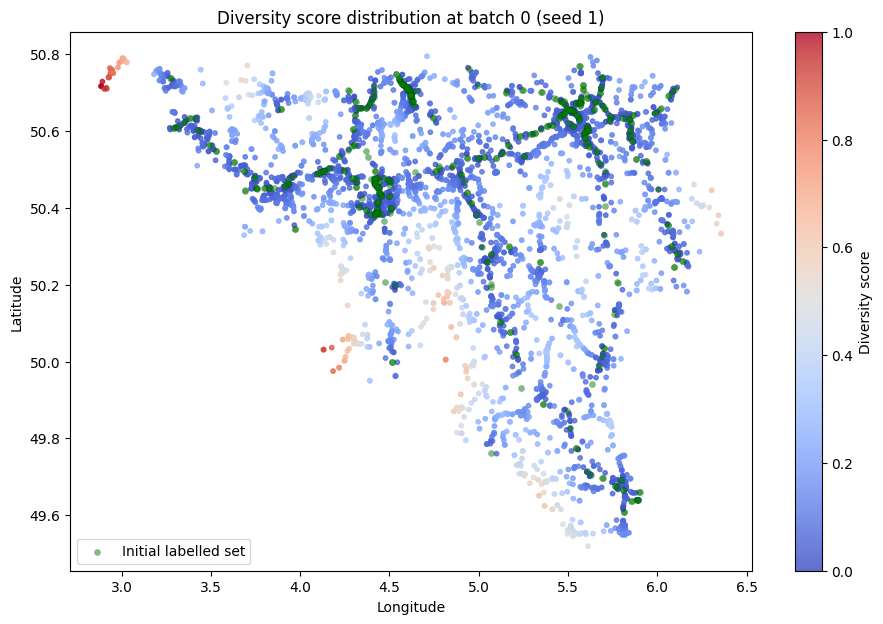

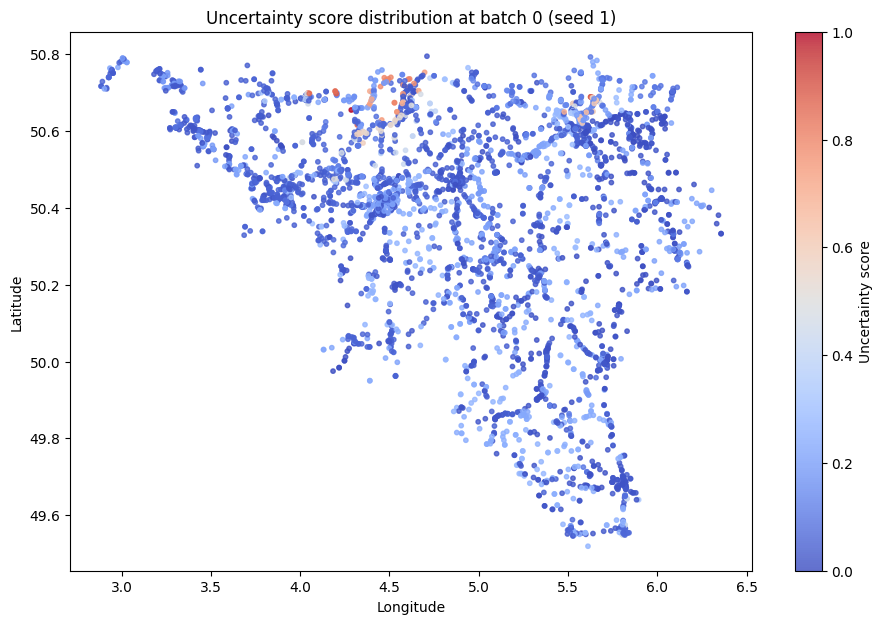

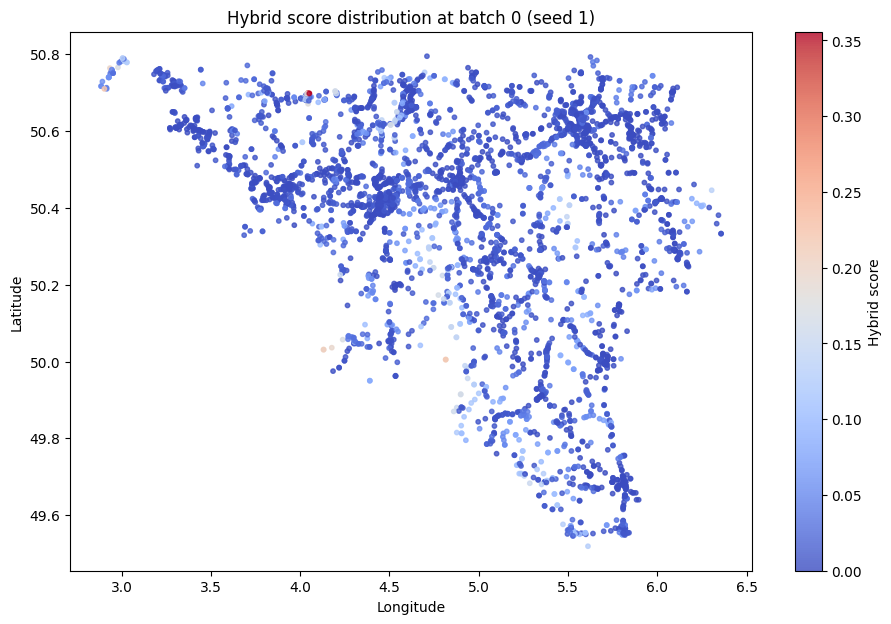

In [2]:
seed = 1
study.analyse_uncertainty_diversity_scores(seed)

## End

This concludes our thesis. We invite to the lector to read the code if they have any doubt about the implementation. If any bug occurs, make sure to run back the cells for the beginning and that the data folders are filled correctly. If the problem persists, please contact the author of this repository.